# Frequency-Domain Notch Filters

**Notch filters** remove **periodic interference** (moiré, scan lines, stripe patterns) by zeroing narrow peaks in the **2D FFT spectrum**.

**Image sources:** `skimage.data.camera` or ECE533 `boat`; synthetic stripe noise added in code.

---

## 1. 2D FFT intuition

Any image can be decomposed into 2D sinusoids. The **DFT magnitude** shows which frequencies are present:
- **Center (DC)** — average brightness
- **Off-center peaks** — repeating patterns at specific spatial frequencies

**Pipeline:** `fft2` → `fftshift` (DC to center) → multiply by filter $H$ → `ifftshift` → `ifft2`

---

## 2. Notch reject filter

Periodic noise appears as **symmetric peak pairs** about DC. A notch filter sets $H(u,v) \approx 0$ at those locations (and their conjugate symmetric partners).

| Type | Formula shape | Behavior |
|------|---------------|----------|
| **Ideal** | 0 inside radius $D_0$ at each peak | Sharp cut-off, visible ringing |
| **Gaussian** | $1 - e^{-d^2 / 2\sigma^2}$ at each peak | Smooth, good default for mesh/stripe removal |
| **Butterworth** | $1 - \dfrac{1}{1 + (d/D_0)^{2n}}$ | Tunable rolloff via order $n$ |

**Placing notches:** for the synthetic stripe noise in this notebook, peak locations follow directly from the parameters used in `add_stripe_noise`:

$$\text{stripe}(x,y) = A\sin\bigl(2\pi f\,(x\cos\theta + y\sin\theta)\bigr)$$

The fundamental peak sits at offset $(f\cos\theta \cdot W,\; f\sin\theta \cdot H)$ from DC. **Clipping to `[0, 255]`** distorts the pure sinusoid and creates **harmonics** at $2f, 3f, \ldots$ on the **same angle** — `stripe_notch_centers()` places notches at every harmonic that fits inside the spectrum.

**Symmetric pairs:** for real images, each interference peak has a conjugate partner mirrored about DC; the filter applies at both locations.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
from pathlib import Path
from urllib.request import urlretrieve
import skimage.data as skid

plt.rcParams.update({
    "figure.figsize": (12, 4),
    "figure.dpi": 100,
    "axes.grid": True,
    "grid.alpha": 0.3,
})

NOTEBOOK_DIR = Path.cwd()
IMAGES_CACHE = NOTEBOOK_DIR.parent / "Images"
IMAGES_CACHE.mkdir(exist_ok=True)

ECE533_URLS = {
    "peppers": "https://homepages.cae.wisc.edu/~ece533/images/peppers.png",
    "boat": "https://homepages.cae.wisc.edu/~ece533/images/boat.png",
    "baboon": "https://homepages.cae.wisc.edu/~ece533/images/baboon.png",
}

SKIMAGE_FALLBACK = {
    "peppers": skid.astronaut,
    "boat": skid.camera,
    "baboon": skid.chelsea,
}


def load_sample_image(name):
    """Load from skimage.data or download Wisconsin ECE533 image (cached locally)."""
    skimg_map = {
        "camera": skid.camera,
        "coins": skid.coins,
        "astronaut": skid.astronaut,
        "coffee": skid.coffee,
        "chelsea": skid.chelsea,
        "page": skid.page,
    }
    if name in skimg_map:
        img = skimg_map[name]()
        if img.ndim == 2:
            return img.astype(np.uint8)
        return cv2.cvtColor(img, cv2.COLOR_RGB2BGR)

    cache_path = IMAGES_CACHE / f"{name}.png"
    if cache_path.exists():
        img = cv2.imread(str(cache_path), cv2.IMREAD_UNCHANGED)
        if img is not None:
            return img

    url = ECE533_URLS.get(name)
    if url:
        try:
            print(f"Downloading {name} from ECE533 ...")
            urlretrieve(url, cache_path)
            img = cv2.imread(str(cache_path), cv2.IMREAD_UNCHANGED)
            if img is not None:
                return img
        except Exception as exc:
            print(f"Download failed ({exc}); using skimage fallback.")

    fallback = SKIMAGE_FALLBACK.get(name, skid.camera)
    img = fallback()
    if img.ndim == 2:
        return img.astype(np.uint8)
    return cv2.cvtColor(img, cv2.COLOR_RGB2BGR)


def to_rgb(bgr):
    if bgr.ndim == 2:
        return bgr
    return cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)


def show_gray(ax, img, title=""):
    ax.imshow(img, cmap="gray", vmin=0, vmax=255)
    ax.set_title(title)
    ax.axis("off")


def show_rgb(ax, img_bgr, title=""):
    ax.imshow(to_rgb(img_bgr))
    ax.set_title(title)
    ax.axis("off")


def side_by_side(images, titles, rgb_flags=None, cols=4):
    """Plot a row/grid of images. images: list of arrays; rgb_flags: True for BGR color."""
    n = len(images)
    cols = min(cols, n)
    rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(3.2 * cols, 3.2 * rows))
    axes = np.atleast_1d(axes).ravel()
    for i, (img, title) in enumerate(zip(images, titles)):
        is_rgb = rgb_flags[i] if rgb_flags else (img.ndim == 3)
        if is_rgb:
            show_rgb(axes[i], img, title)
        else:
            show_gray(axes[i], img, title)
    for j in range(n, len(axes)):
        axes[j].axis("off")
    plt.tight_layout()
    plt.show()


def add_salt_pepper(gray, amount=0.05):
    """Inject salt-and-pepper noise into a uint8 grayscale image."""
    out = gray.copy()
    n = int(amount * gray.size)
    rng = np.random.default_rng(42)
    coords = (rng.integers(0, gray.shape[0], n), rng.integers(0, gray.shape[1], n))
    out[coords] = 255
    coords = (rng.integers(0, gray.shape[0], n), rng.integers(0, gray.shape[1], n))
    out[coords] = 0
    return out


def spectrum_uint8(gray):
    f = np.fft.fft2(gray.astype(np.float64))
    fshift = np.fft.fftshift(f)
    mag = np.log1p(np.abs(fshift))
    mag = (mag - mag.min()) / (mag.max() - mag.min() + 1e-12) * 255
    return fshift, mag.astype(np.uint8)


def filtered_spectrum_uint8(gray, notch_filter):
    """Log-magnitude spectrum after multiplying by H (shows notch locations)."""
    _, fshift = compute_fourier(gray)
    mag = np.log1p(np.abs(fshift * notch_filter))
    mag = (mag - mag.min()) / (mag.max() - mag.min() + 1e-12) * 255
    return mag.astype(np.uint8)


def add_stripe_noise(gray, freq=0.15, angle_deg=30, amplitude=25):
    """Add sinusoidal stripe interference; freq in cycles/pixel, angle in degrees."""
    h, w = gray.shape
    yy, xx = np.mgrid[0:h, 0:w]
    theta = np.deg2rad(angle_deg)
    stripes = amplitude * np.sin(2 * np.pi * freq * (xx * np.cos(theta) + yy * np.sin(theta)))
    out = np.clip(gray.astype(np.float64) + stripes, 0, 255).astype(np.uint8)
    return out


def stripe_notch_centers(shape, freq, angle_deg):
    """Symmetric FFT peaks along the stripe direction .

    """
    h, w = shape
    cy, cx = h // 2, w // 2
    theta = np.deg2rad(angle_deg)
    dx = freq * np.cos(theta) * w
    dy = freq * np.sin(theta) * h

    peaks = set()
    for sign in (1, -1):
        py = int(round(cy + sign  * dy))
        px = int(round(cx + sign  * dx))
        if 0 <= py < h and 0 <= px < w:
            peaks.add((py, px))
    return sorted(peaks)


def compute_fourier(image_array):
    f_transform = np.fft.fft2(image_array.astype(np.float64))
    f_transform_shifted = np.fft.fftshift(f_transform)
    return f_transform, f_transform_shifted


def compute_magnitude_spectrum(f_transform_shifted):
    return np.abs(f_transform_shifted)


def create_notch_filter(size, peaks, filter_type="gaussian", D0=11, order=2):
    """Build a multi-notch reject filter H(u,v) in shifted frequency coordinates."""
    h, w = size
    u, v = np.meshgrid(np.arange(w), np.arange(h))
    notch_filter = np.ones(size, dtype=np.float64)
    for py, px in peaks:
        distance_sq = (u - px) ** 2 + (v - py) ** 2
        if filter_type == "ideal":
            notch_filter *= np.where(distance_sq <= D0 ** 2, 0.0, 1.0)
        elif filter_type == "gaussian":
            notch_filter *= 1.0 - np.exp(-distance_sq / (2.0 * D0 ** 2))
        elif filter_type == "butterworth":
            D = np.sqrt(distance_sq + 1e-12)
            notch_filter *= 1.0 - 1.0 / (1.0 + (D / (D0 + 1e-6)) ** (2 * order))
        else:
            raise ValueError("filter_type must be 'ideal', 'gaussian', or 'butterworth'.")
    return notch_filter


def apply_notch_filter(image_array, notch_filter):
    _, f_transform_shifted = compute_fourier(image_array)
    filtered_shifted = f_transform_shifted * notch_filter
    filtered = np.fft.ifftshift(filtered_shifted)
    restored = np.fft.ifft2(filtered)
    return np.clip(np.real(restored), 0, 255).astype(np.uint8)


def apply_stripe_notch(img, freq, angle_deg, filter_type="gaussian", D0=11, order=2):
    """Notch-filter using centers derived from known stripe noise parameters."""
    peaks = stripe_notch_centers(img.shape, freq, angle_deg)
    notch_filter = create_notch_filter(img.shape, peaks, filter_type, D0, order)
    filtered = apply_notch_filter(img, notch_filter)
    return notch_filter, filtered, peaks


def butterworth_notch(H, W, centers, D0=8, n=2):
    """Legacy wrapper — kept for manual center specification."""
    return create_notch_filter((H, W), centers, "butterworth", D0, n)


def apply_freq_filter(gray, Hfilt):
    return apply_notch_filter(gray, Hfilt)


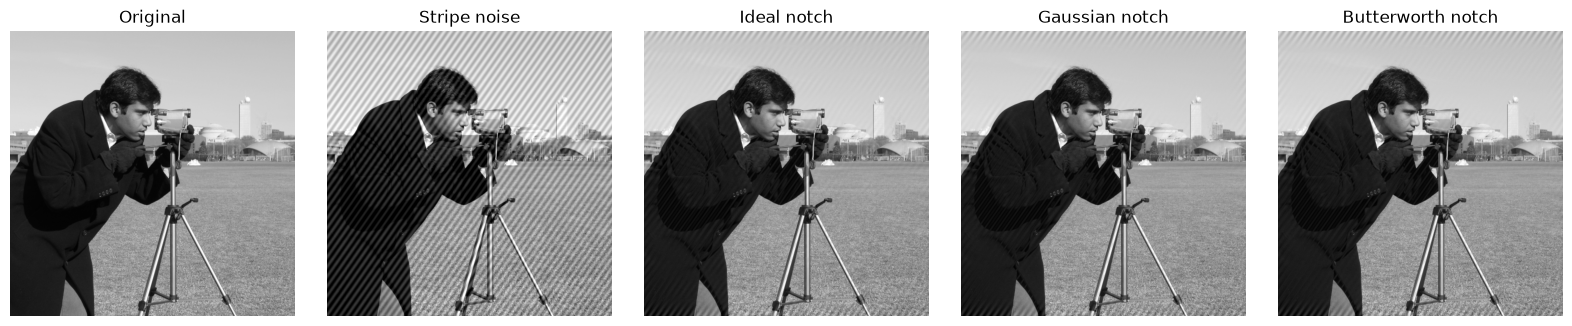

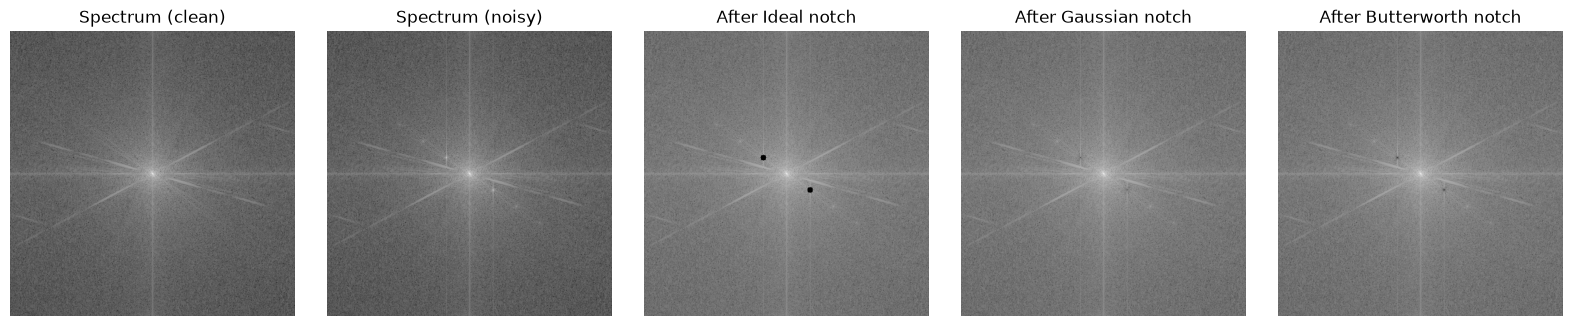

Notch centers (row, col): [(227, 214), (285, 298)]  (2 peaks incl. harmonics)
Stripe params: freq=0.1, angle=35°


In [2]:
img = load_sample_image("camera")

STRIPE_FREQ = 0.1
STRIPE_ANGLE = 35
noisy = add_stripe_noise(img, freq=STRIPE_FREQ, angle_deg=STRIPE_ANGLE, amplitude=30)

_, spec_clean = spectrum_uint8(img)
_, spec_noisy = spectrum_uint8(noisy)

# Notch centers from the same freq/angle used to create the stripe noise
peaks = stripe_notch_centers(noisy.shape, STRIPE_FREQ, STRIPE_ANGLE)

filter_types = ["ideal", "gaussian", "butterworth"]
denoised = {}
spec_filtered = []
H_gauss = create_notch_filter(noisy.shape, peaks, "gaussian", D0=5, order=2)
for ftype in filter_types:
    Hfilt = create_notch_filter(noisy.shape, peaks, ftype, D0=5, order=2)
    denoised[ftype] = apply_notch_filter(noisy, Hfilt)
    spec_filtered.append(filtered_spectrum_uint8(noisy, Hfilt))
denoised_gaussian = denoised["gaussian"]
side_by_side(
    [img, noisy] + [denoised[t] for t in filter_types],
    ["Original", "Stripe noise"] + [f"{t.title()} notch" for t in filter_types],
    cols=5,
)
side_by_side(
    [spec_clean, spec_noisy, *spec_filtered],
    ["Spectrum (clean)", "Spectrum (noisy)", *[f"After {t.title()} notch" for t in filter_types]],
    cols=5,
)

print(f"Notch centers (row, col): {peaks}  ({len(peaks)} peaks incl. harmonics)")
print(f"Stripe params: freq={STRIPE_FREQ}, angle={STRIPE_ANGLE}°")


## 3. Notch vs low-pass / high-pass

| Filter | Removes | Example artifact |
|--------|---------|------------------|
| **Low-pass** | High frequencies everywhere | fine texture, noise |
| **High-pass** | Low frequencies (DC neighborhood) | slow illumination drift |
| **Notch** | Specific frequency **peaks** | periodic stripes, mesh patterns |

Notch filters are **surgical** — they target known interference without blurring the whole image.


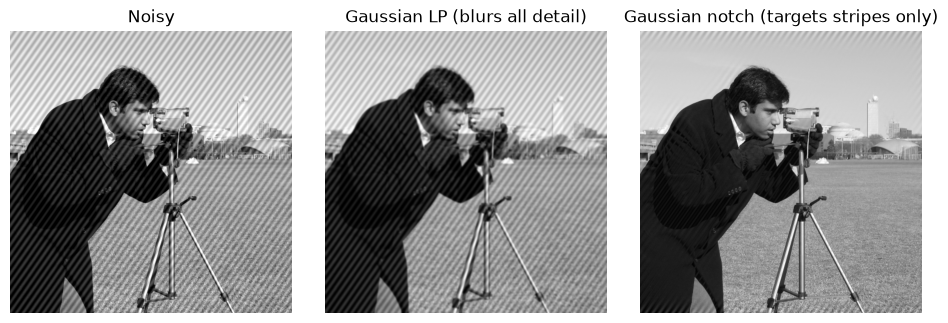

In [3]:
# Compare: Gaussian low-pass on noisy image vs notch
lp = cv2.GaussianBlur(noisy, (5, 5), 0)
side_by_side(
    [noisy, lp, denoised_gaussian],
    ["Noisy", "Gaussian LP (blurs all detail)", "Gaussian notch (targets stripes only)"],
)


## 4. Summary

1. Periodic noise → **spikes** in FFT magnitude (symmetric about DC).
2. For known stripe parameters, `stripe_notch_centers(freq, angle)` places notches at the fundamental.
3. `create_notch_filter` supports **ideal**, **Gaussian**, and **Butterworth** reject profiles.
4. Gaussian / Butterworth reduce ringing compared to ideal notch.
5. Use `numpy.fft`; `cv2.dft` is equivalent but uses different layout conventions.
